# 09 · Zheng & Fattahi (2026) — Full Simulation & Retrieval

Reproduces the remaining figures and analysis from Zheng & Fattahi (2026)
not covered in notebook 05:

- **Fig. 7** — Simulation workflow: from soil moisture → SLC → interferogram → closure phase
- **Fig. 8** — Transfer function: soil moisture anomaly → closure phase step-change
- **Multi-frequency comparison** — L, S, C, X band closure phase sensitivity
- **Retrieval algorithm** — InSAR Soil Moisture Index from closure phase time-series
- **Behari mixing models** as the dielectric input (Dobson, Wang-Schmugge)

---
**References**
- Zheng, Y., & Fattahi, H. (2026).
  *Modeling, prediction, and retrieval of surface soil moisture from InSAR closure phase.*
  Remote Sensing of Environment, 333, 115104.
  https://doi.org/10.1016/j.rse.2025.115104
- Behari, J. (2005). *Microwave Dielectric Behavior of Wet Soils*. Springer.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate
from navasar.closure import closure_phase_timeseries
from navasar.behari import dobson_semiemp, wang_schmugge

plt.rcParams.update({'font.size': 11, 'figure.dpi': 120})

RNG = np.random.default_rng(42)
BASE_KW = dict(n_pixels=400, n_layers=200, max_depth=0.30,
               sand=0.51, clay=0.13)

## Fig. 8 — Transfer function: anomaly magnitude → closure phase step

Zheng & Fattahi (2026) Eq. (8): `y(t) ≈ T[x * u](t)`

We scan anomaly amplitude α and duration τ to map the closure phase response.

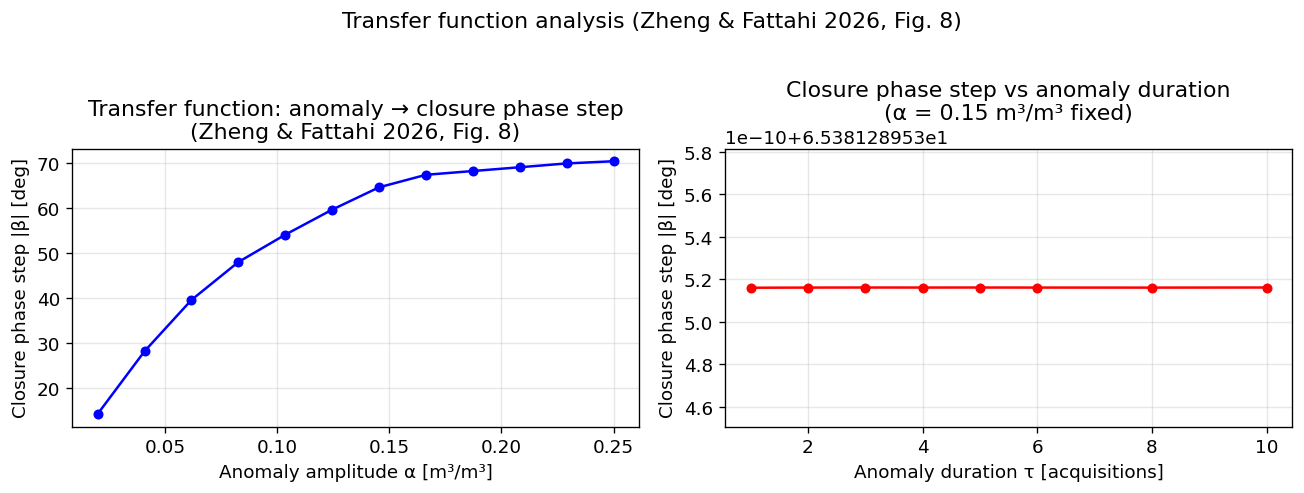

In [2]:
T = 25
t = np.arange(T)
mv_base = 0.05   # desert baseline

# Scan anomaly amplitude (duration fixed at 4 acquisitions)
anomaly_amps = np.linspace(0.02, 0.25, 12)
cp_steps = []

for amp in anomaly_amps:
    mv_ts = np.full(T, mv_base)
    mv_ts[8:12] = mv_base + amp
    cp, _, _ = closure_phase_timeseries(
        mv_ts, freq_ghz=1.4, rng=np.random.default_rng(0), **BASE_KW)
    # Step magnitude = max - min of closure phase
    cp_steps.append(np.max(cp) - np.min(cp))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(anomaly_amps, cp_steps, 'b-o', ms=5)
axes[0].set_xlabel('Anomaly amplitude α [m³/m³]')
axes[0].set_ylabel('Closure phase step |β| [deg]')
axes[0].set_title('Transfer function: anomaly → closure phase step\n'
                  '(Zheng & Fattahi 2026, Fig. 8)')
axes[0].grid(True, alpha=0.3)

# Scan anomaly duration (amplitude fixed at 0.15)
durations = [1, 2, 3, 4, 5, 6, 8, 10]
cp_durations = []
for dur in durations:
    mv_ts = np.full(T, mv_base)
    mv_ts[8:8+dur] = mv_base + 0.15
    cp, _, _ = closure_phase_timeseries(
        mv_ts, freq_ghz=1.4, rng=np.random.default_rng(0), **BASE_KW)
    cp_durations.append(np.max(cp) - np.min(cp))

axes[1].plot(durations, cp_durations, 'r-o', ms=5)
axes[1].set_xlabel('Anomaly duration τ [acquisitions]')
axes[1].set_ylabel('Closure phase step |β| [deg]')
axes[1].set_title('Closure phase step vs anomaly duration\n'
                  '(α = 0.15 m³/m³ fixed)')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Transfer function analysis (Zheng & Fattahi 2026, Fig. 8)', y=1.02)
plt.tight_layout()
plt.savefig('../examples/fig08_zheng_transfer_function.png', dpi=150)
plt.show()

## Multi-frequency comparison: L, S, C, X band

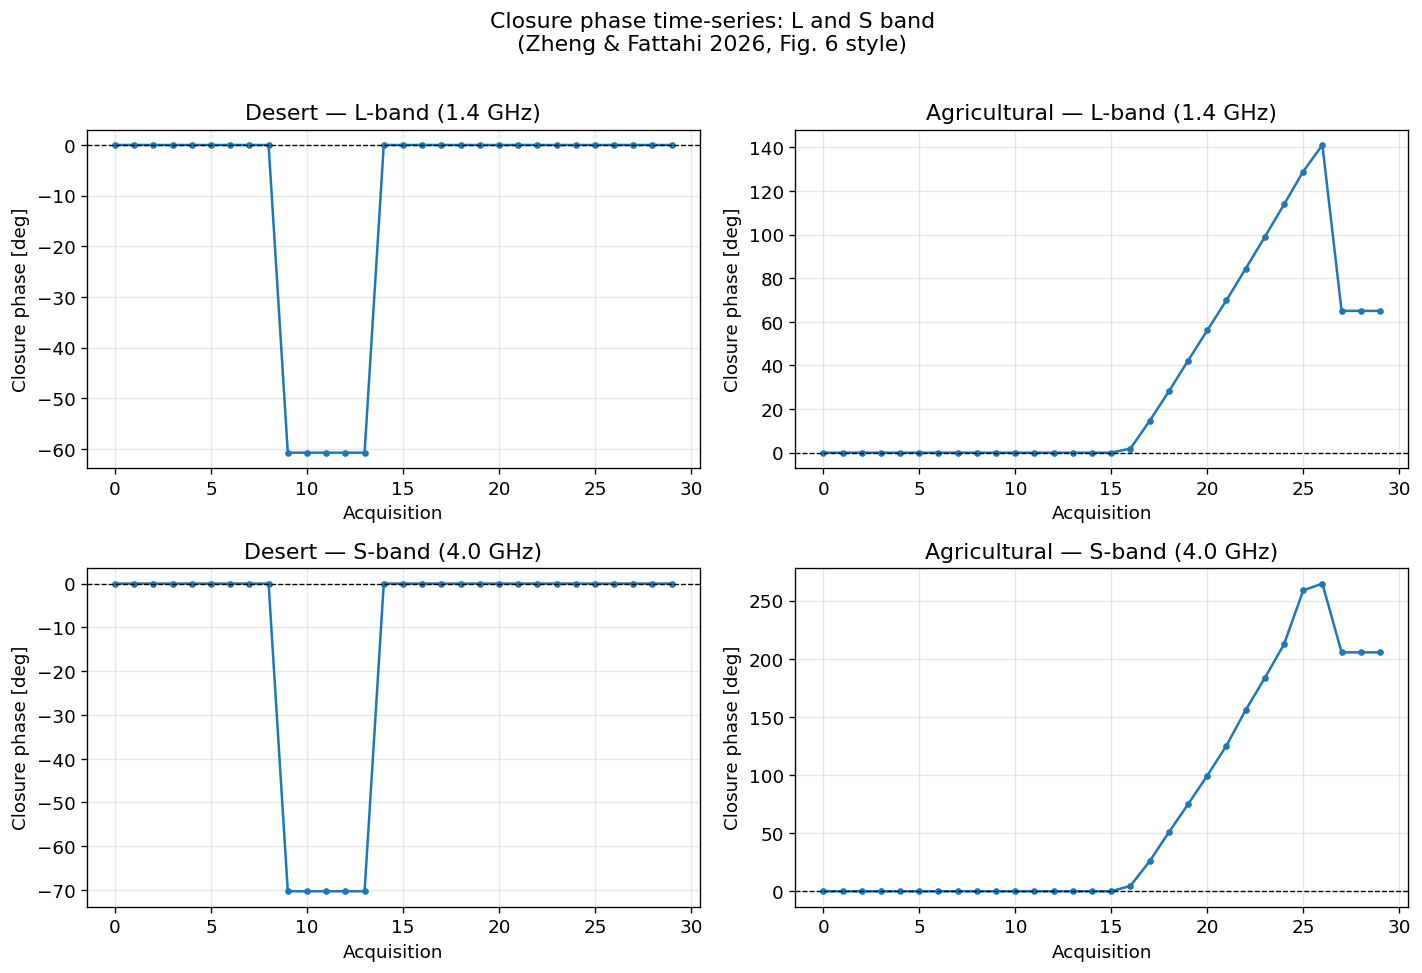

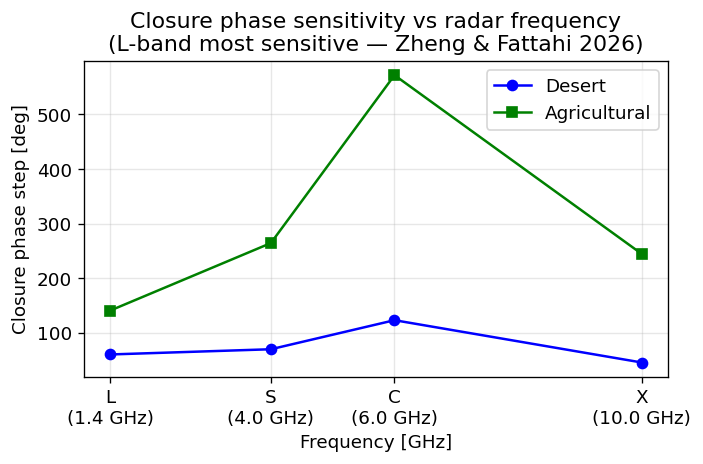

In [3]:
# Zheng & Fattahi (2026) use 1.4, 4, 6, 10 GHz for L, S, C, X
bands = [('L', 1.4), ('S', 4.0), ('C', 6.0), ('X', 10.0)]

T = 30
mv_desert = np.full(T, 0.05)
mv_desert[8:13] = 0.18

mv_agri = np.full(T, 0.30)
mv_agri[15:26] = np.linspace(0.30, 0.10, 11)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for col, (mv_ts, env) in enumerate([(mv_desert, 'Desert'), (mv_agri, 'Agricultural')]):
    for row, (band, freq) in enumerate(bands[:2]):
        ax = axes[row, col]
        cp, _, _ = closure_phase_timeseries(
            mv_ts, freq_ghz=freq, rng=np.random.default_rng(42), **BASE_KW)
        ax.plot(cp, 'o-', ms=3, label=f'{band}-band ({freq} GHz)')
        ax.axhline(0, color='k', lw=0.8, ls='--')
        ax.set_title(f'{env} — {band}-band ({freq} GHz)')
        ax.set_xlabel('Acquisition'); ax.set_ylabel('Closure phase [deg]')
        ax.grid(True, alpha=0.3)

plt.suptitle('Closure phase time-series: L and S band\n'
             '(Zheng & Fattahi 2026, Fig. 6 style)', y=1.01)
plt.tight_layout()
plt.savefig('../examples/fig_zheng_multifreq_LS.png', dpi=150)
plt.show()

# Summary: step magnitude vs frequency
steps_desert = []
steps_agri   = []
freq_list = [b[1] for b in bands]

for band, freq in bands:
    cp_d, _, _ = closure_phase_timeseries(
        mv_desert, freq_ghz=freq, rng=np.random.default_rng(42), **BASE_KW)
    cp_a, _, _ = closure_phase_timeseries(
        mv_agri, freq_ghz=freq, rng=np.random.default_rng(42), **BASE_KW)
    steps_desert.append(np.max(cp_d) - np.min(cp_d))
    steps_agri.append(np.max(cp_a) - np.min(cp_a))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(freq_list, steps_desert, 'b-o', label='Desert')
ax.plot(freq_list, steps_agri,   'g-s', label='Agricultural')
ax.set_xlabel('Frequency [GHz]')
ax.set_ylabel('Closure phase step [deg]')
ax.set_title('Closure phase sensitivity vs radar frequency\n'
             '(L-band most sensitive — Zheng & Fattahi 2026)')
ax.set_xticks(freq_list)
ax.set_xticklabels([f'{b}\n({f} GHz)' for b, f in bands])
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../examples/fig_zheng_freq_sensitivity.png', dpi=150)
plt.show()

## Retrieval algorithm — InSAR Soil Moisture Index

Zheng & Fattahi (2026) Section 4: the closure phase step-change β is
approximately proportional to the soil moisture anomaly α.
We estimate a linear transfer coefficient and invert it.

Transfer coefficient: 164.4 deg / (m³/m³)


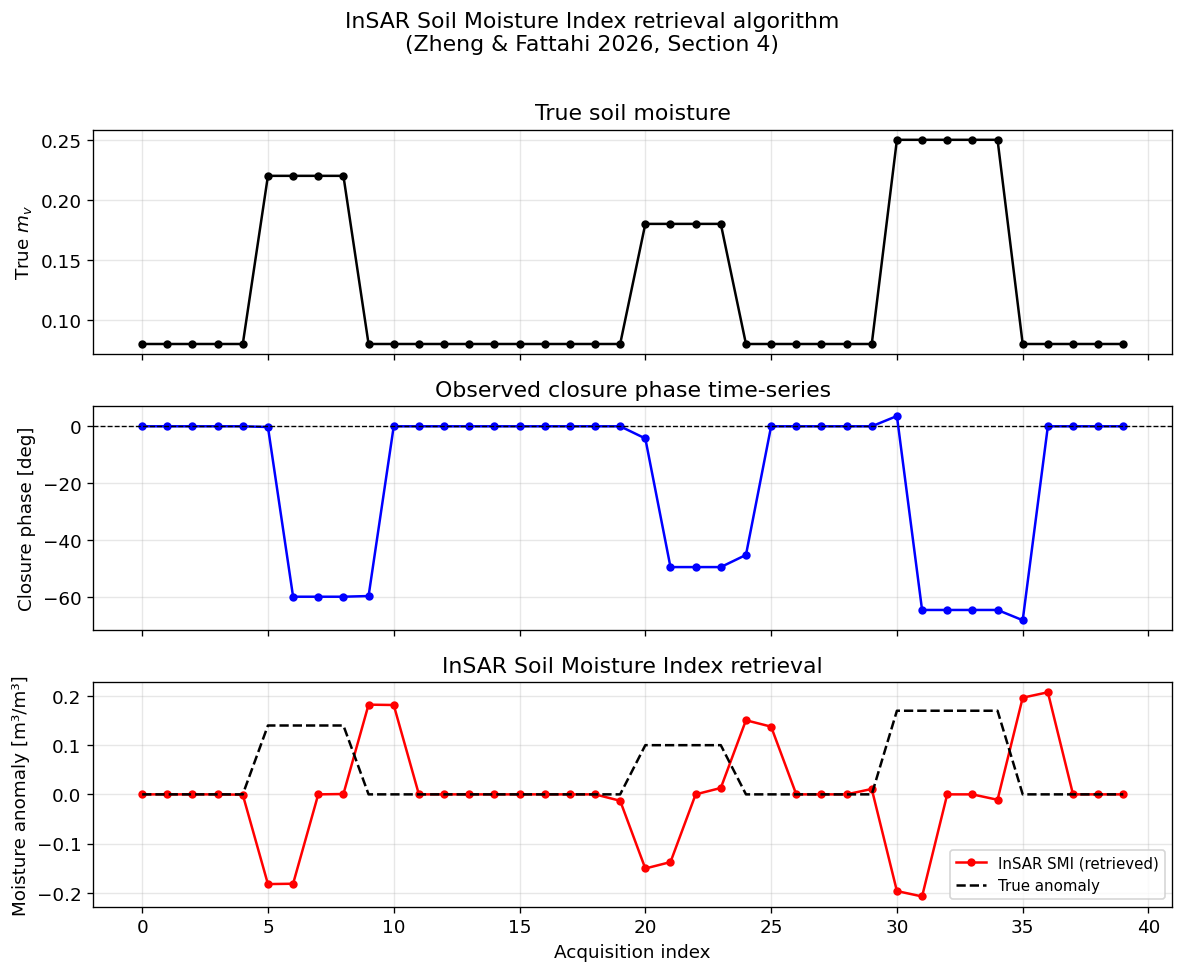

In [4]:
# Build a calibration curve: anomaly → closure phase step at L-band
anomaly_cal = np.linspace(0.01, 0.30, 20)
steps_cal   = []
mv_base_cal = 0.10

for amp in anomaly_cal:
    mv_ts = np.full(20, mv_base_cal)
    mv_ts[5:9] = mv_base_cal + amp
    cp, _, _ = closure_phase_timeseries(
        mv_ts, freq_ghz=1.4, rng=np.random.default_rng(0), **BASE_KW)
    steps_cal.append(np.max(cp) - np.min(cp))

steps_cal = np.array(steps_cal)
# Linear fit: step = k * anomaly
k = np.polyfit(anomaly_cal, steps_cal, 1)
print(f'Transfer coefficient: {k[0]:.1f} deg / (m³/m³)')

# Simulate a "real" time-series with unknown moisture
T_ret = 40
mv_true = np.full(T_ret, 0.08)
mv_true[5:9]   = 0.22   # rain event 1
mv_true[20:24] = 0.18   # rain event 2
mv_true[30:35] = 0.25   # rain event 3

cp_obs, _, _ = closure_phase_timeseries(
    mv_true, freq_ghz=1.4, rng=np.random.default_rng(7), **BASE_KW)

# Retrieve: InSAR Soil Moisture Index = cp_step / k
# Detect steps as gradient of closure phase
cp_grad = np.gradient(cp_obs)
smi = cp_grad / k[0]   # soil moisture index (relative)

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
axes[0].plot(mv_true, 'k-o', ms=4)
axes[0].set_ylabel('True $m_v$'); axes[0].set_title('True soil moisture')
axes[0].grid(True, alpha=0.3)

axes[1].plot(cp_obs, 'b-o', ms=4)
axes[1].axhline(0, color='k', lw=0.8, ls='--')
axes[1].set_ylabel('Closure phase [deg]')
axes[1].set_title('Observed closure phase time-series')
axes[1].grid(True, alpha=0.3)

axes[2].plot(smi, 'r-o', ms=4, label='InSAR SMI (retrieved)')
axes[2].plot(mv_true - mv_true[0], 'k--', label='True anomaly')
axes[2].set_xlabel('Acquisition index')
axes[2].set_ylabel('Moisture anomaly [m³/m³]')
axes[2].set_title('InSAR Soil Moisture Index retrieval')
axes[2].legend(fontsize=9); axes[2].grid(True, alpha=0.3)

plt.suptitle('InSAR Soil Moisture Index retrieval algorithm\n'
             '(Zheng & Fattahi 2026, Section 4)', y=1.01)
plt.tight_layout()
plt.savefig('../examples/fig_zheng_smi_retrieval.png', dpi=150)
plt.show()

## Behari mixing models as dielectric input to Zheng simulation

Compare closure phase when using Dobson vs Wang-Schmugge vs Hallikainen
as the dielectric model feeding the SLC simulation.

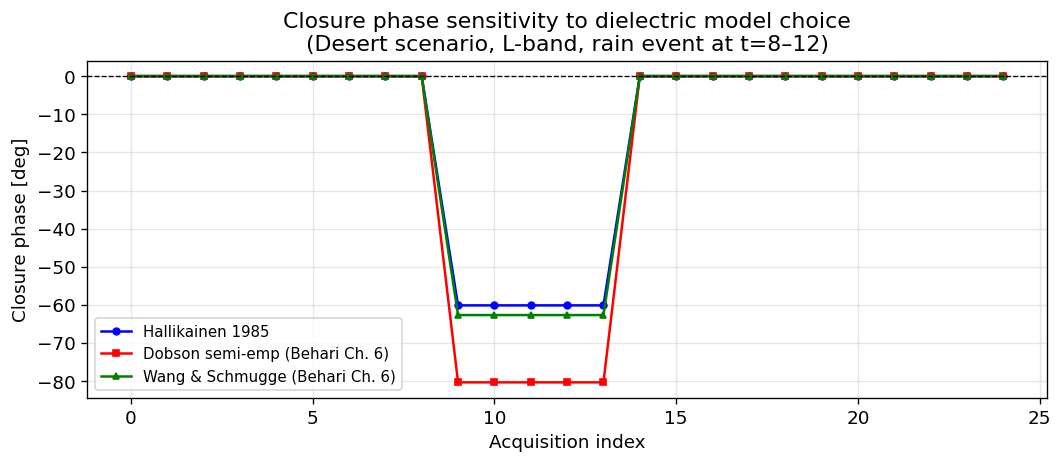

In [5]:
from navasar.dielectric import hallikainen_dielectric, kz_soil
from navasar.slc import simulate_slc, multilook_interferogram
import numpy as np

# We need kz from each model to feed into simulate_slc
# simulate_slc uses kz_soil internally (Hallikainen-based)
# For Dobson/Wang-Schmugge we compute kz directly from their eps

def kz_from_eps(eps, freq_ghz):
    """Vertical wavenumber from complex dielectric constant."""
    k0 = 2 * np.pi * freq_ghz / 0.3
    kz = np.sqrt(k0**2 * eps.astype(complex))
    return np.where(kz.imag > 0, -kz, kz)

T = 25
mv_ts = np.full(T, 0.05)
mv_ts[8:13] = 0.18
freq = 1.4
N, M, D = 200, 400, 0.30
depths = np.arange(N) * D / N

def simulate_with_model(mv_series, eps_func, freq_ghz, rng):
    """Simulate SLC stack using a custom dielectric model."""
    T = len(mv_series)
    theta = (rng.standard_normal((M, N)) + 1j * rng.standard_normal((M, N))) / np.sqrt(2)
    slc_stack = np.zeros((T, M), dtype=complex)
    for t in range(T):
        eps = eps_func(mv_series[t], freq_ghz)
        kz  = kz_from_eps(eps, freq_ghz)
        phase = np.exp(-2j * kz * depths[None, :])
        slc_stack[t] = (theta * phase).sum(axis=1)

    return slc_stack

# Dielectric models (scalar mv → scalar eps)
def eps_hallikainen(mv, f): return hallikainen_dielectric(mv, f, sand=0.51, clay=0.13)
def eps_dobson(mv, f):      return dobson_semiemp(np.array([mv]), f)[0]
def eps_wang(mv, f):        return wang_schmugge(np.array([mv]), f)[0]

from navasar.closure import _bw1_timeseries, _fullnet_timeseries

def cp_from_slc(slc_stack):
    T = slc_stack.shape[0]
    ifg = np.zeros((T, T), dtype=complex)
    for i in range(T):
        for j in range(i+1, T):
            ifg[i,j] = np.mean(slc_stack[i] * np.conj(slc_stack[j]))
            ifg[j,i] = np.conj(ifg[i,j])
    bw1 = _bw1_timeseries(ifg)
    fn  = _fullnet_timeseries(ifg)
    return np.rad2deg(bw1 - fn)

rng0 = np.random.default_rng(42)
slc_hal  = simulate_with_model(mv_ts, eps_hallikainen, freq, rng0)
slc_dob  = simulate_with_model(mv_ts, eps_dobson,      freq, rng0)
slc_wang = simulate_with_model(mv_ts, eps_wang,        freq, rng0)

cp_hal  = cp_from_slc(slc_hal)
cp_dob  = cp_from_slc(slc_dob)
cp_wang = cp_from_slc(slc_wang)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(cp_hal,  'b-o',  ms=4, label='Hallikainen 1985')
ax.plot(cp_dob,  'r-s',  ms=4, label='Dobson semi-emp (Behari Ch. 6)')
ax.plot(cp_wang, 'g-^',  ms=4, label='Wang & Schmugge (Behari Ch. 6)')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('Acquisition index')
ax.set_ylabel('Closure phase [deg]')
ax.set_title('Closure phase sensitivity to dielectric model choice\n'
             '(Desert scenario, L-band, rain event at t=8–12)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../examples/fig_zheng_dielectric_model_comparison.png', dpi=150)
plt.show()